# Esperimento con differenti Lora rank per l'extractor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast

In [3]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<StringArray>
[                'qwen-chat-agent-4-v2',
                       'chat-qwen-base',
                    'qwen-chat-agent-6',
                     'qwen-extractor-3',
                     'qwen-extractor-4',
                     'qwen-extractor-2',
 'qwen-chat-extractor-tuned-lora-16-v1',
                 'qwen-chat-agent-5-v1',
                    'qwen-chat-agent-7',
       'qwen-chat-agent-8-wo-embedding',
                   'qwen-chat-agent-12',
                    'qwen-chat-agent-9',
             'qwen-extractor-5-lora-32']
Length: 13, dtype: str

In [5]:
target ='base|v4|qwen-extractor-5-lora-32|qwen-extractor-4'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base','qwen-extractor-rank-16', 'qwen-extractor-rank-32']
models

['chat-qwen-base', 'qwen-extractor-4', 'qwen-extractor-5-lora-32']

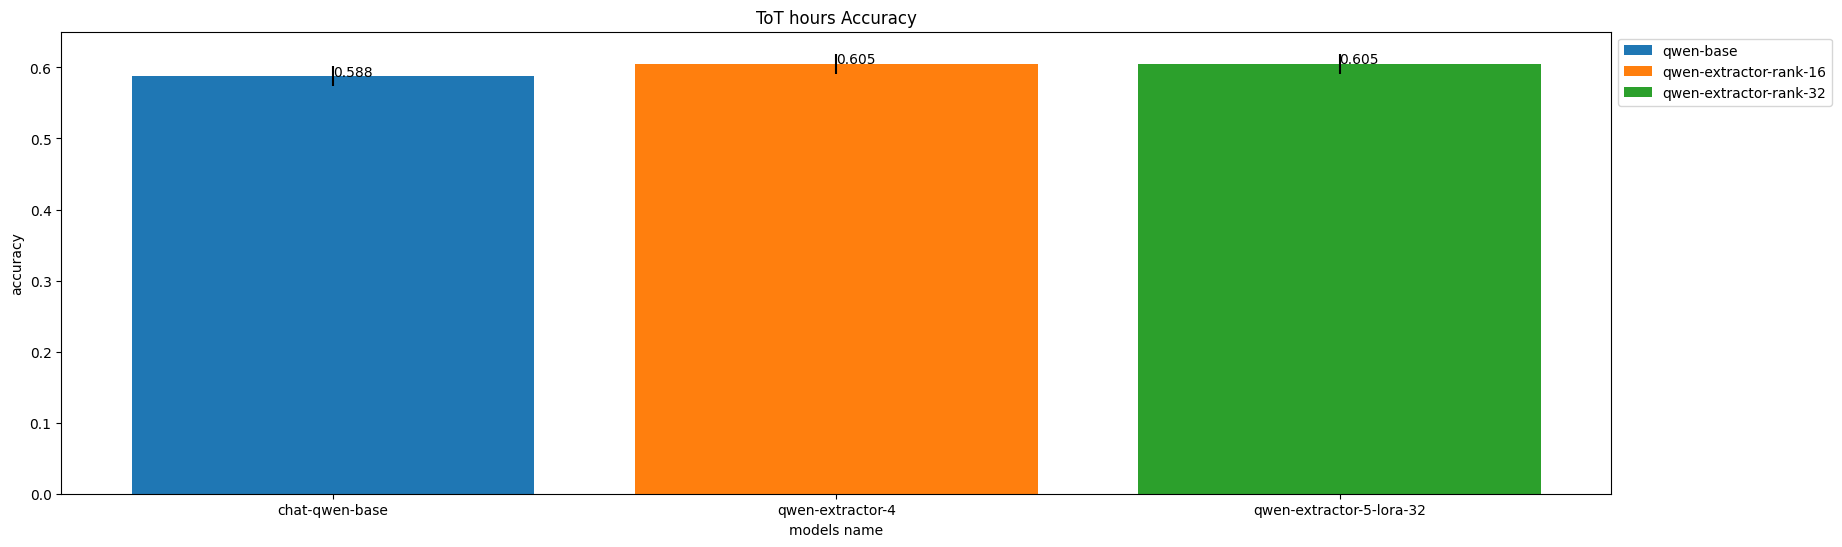

In [6]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

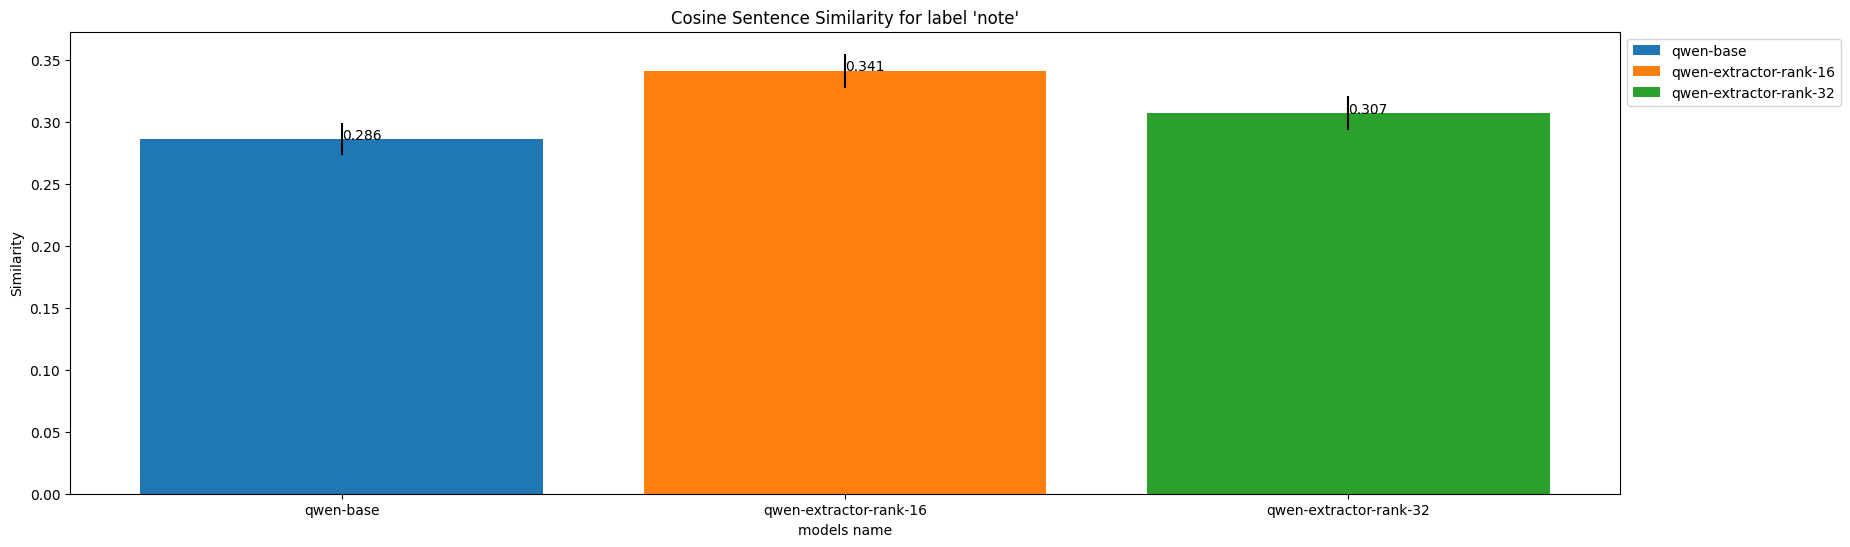

In [7]:
# cosine similarity del campo note con Sentence similarity
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
models = list(df[df['model'].str.contains(target)]['model'].unique())
for model in models:
    acc_media = round(df.loc[(df['model'] == model)  & (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Cosine Sentence Similarity for label 'note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

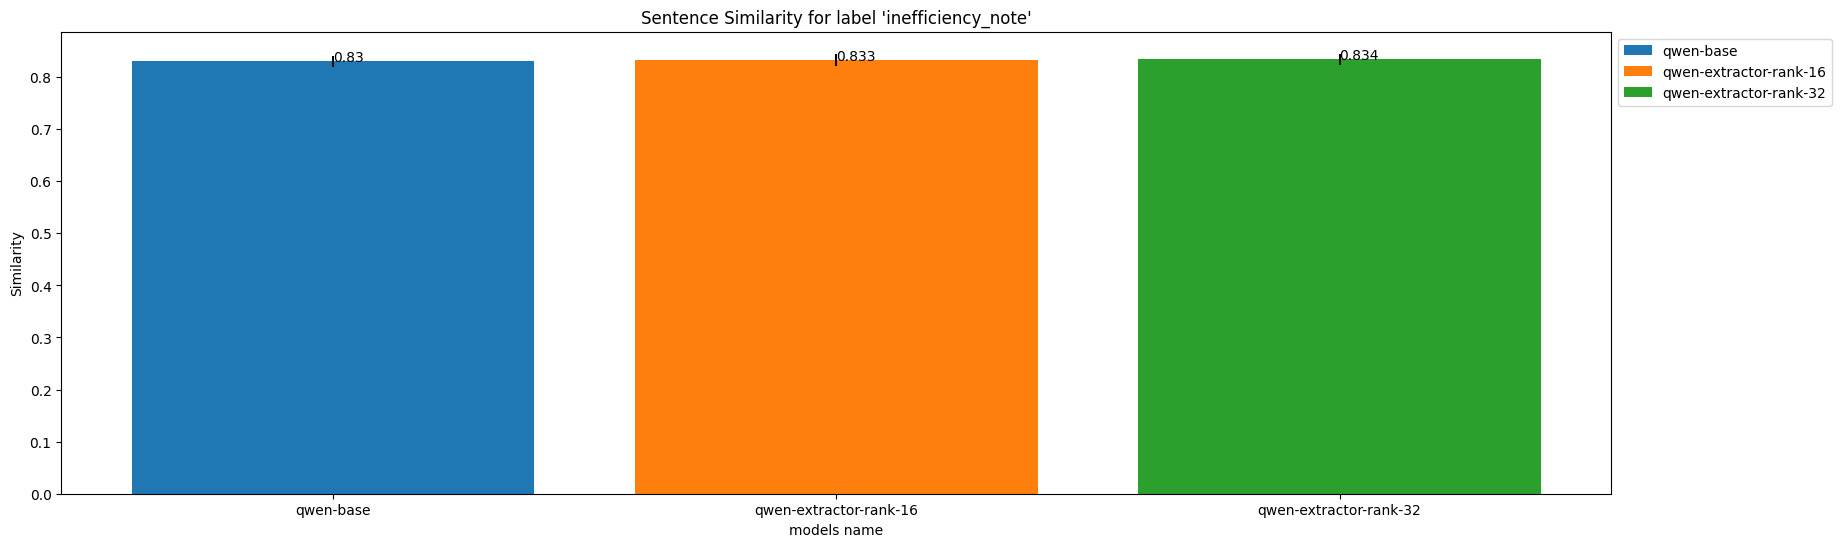

In [8]:
# cosine similarity campo inefficiency desciption
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['sentence_similarity_score_inefficiency'].isna() != True)]['sentence_similarity_score_inefficiency'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Sentence Similarity for label 'inefficiency_note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

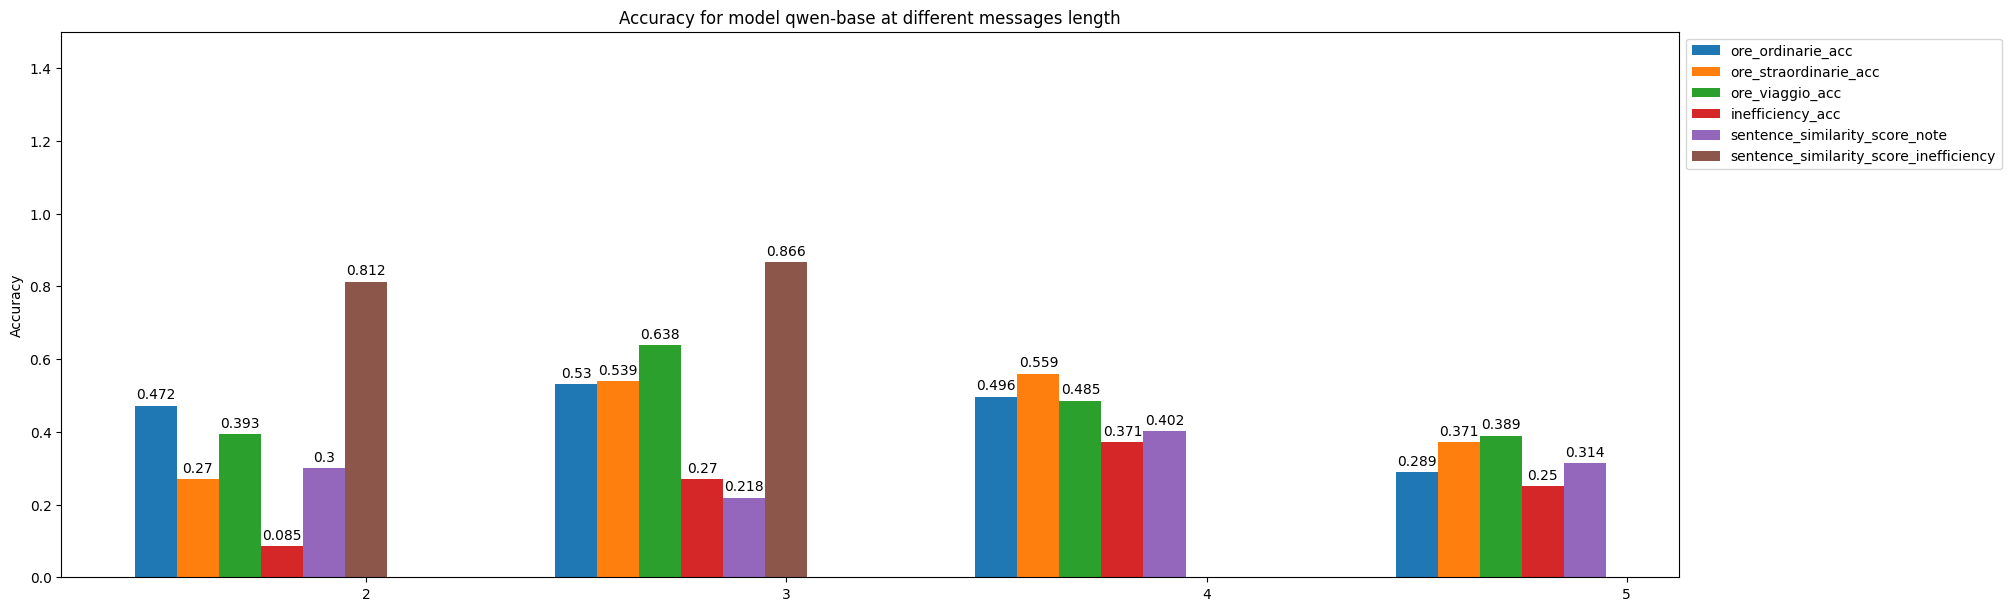

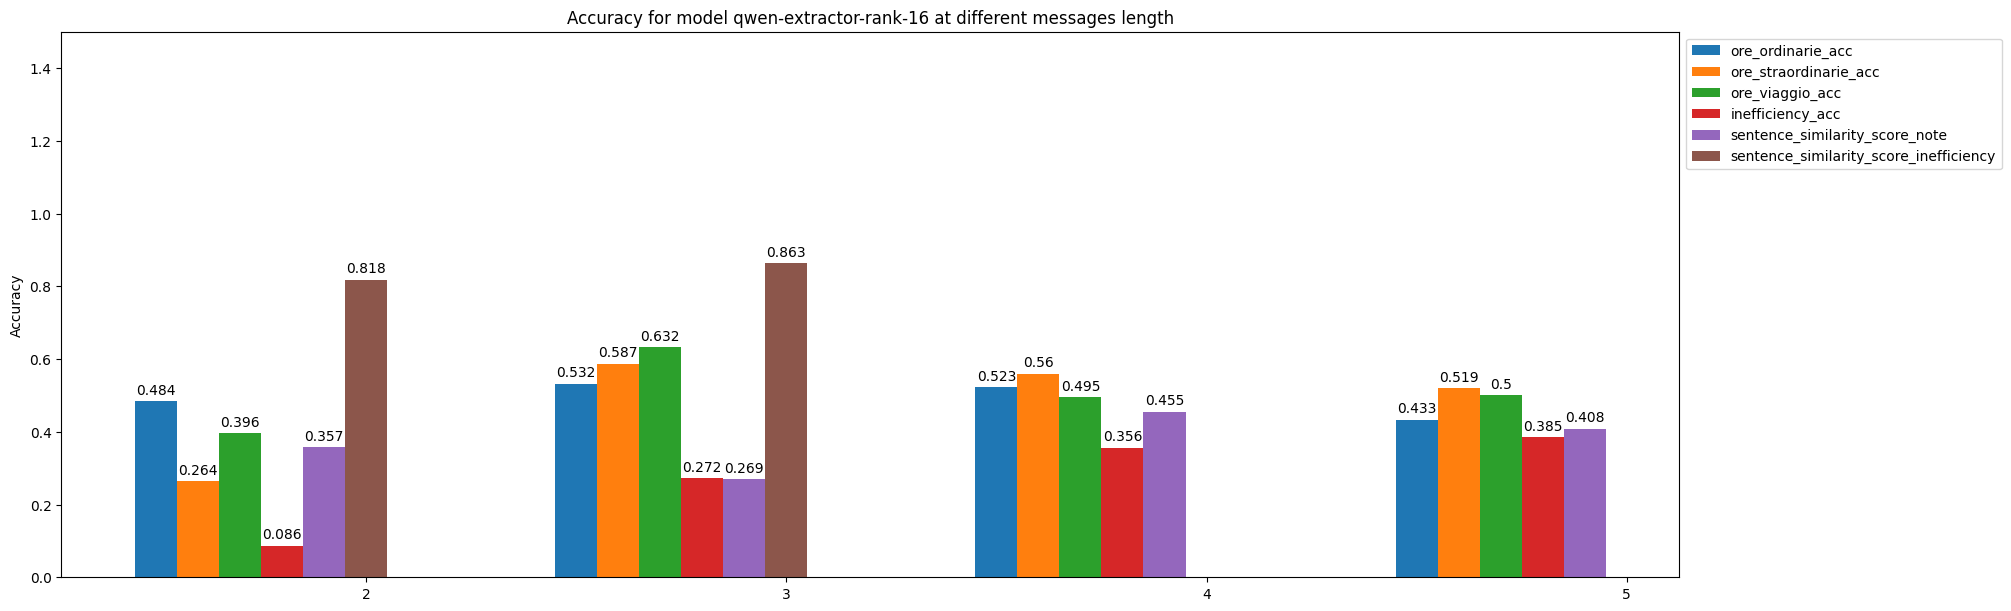

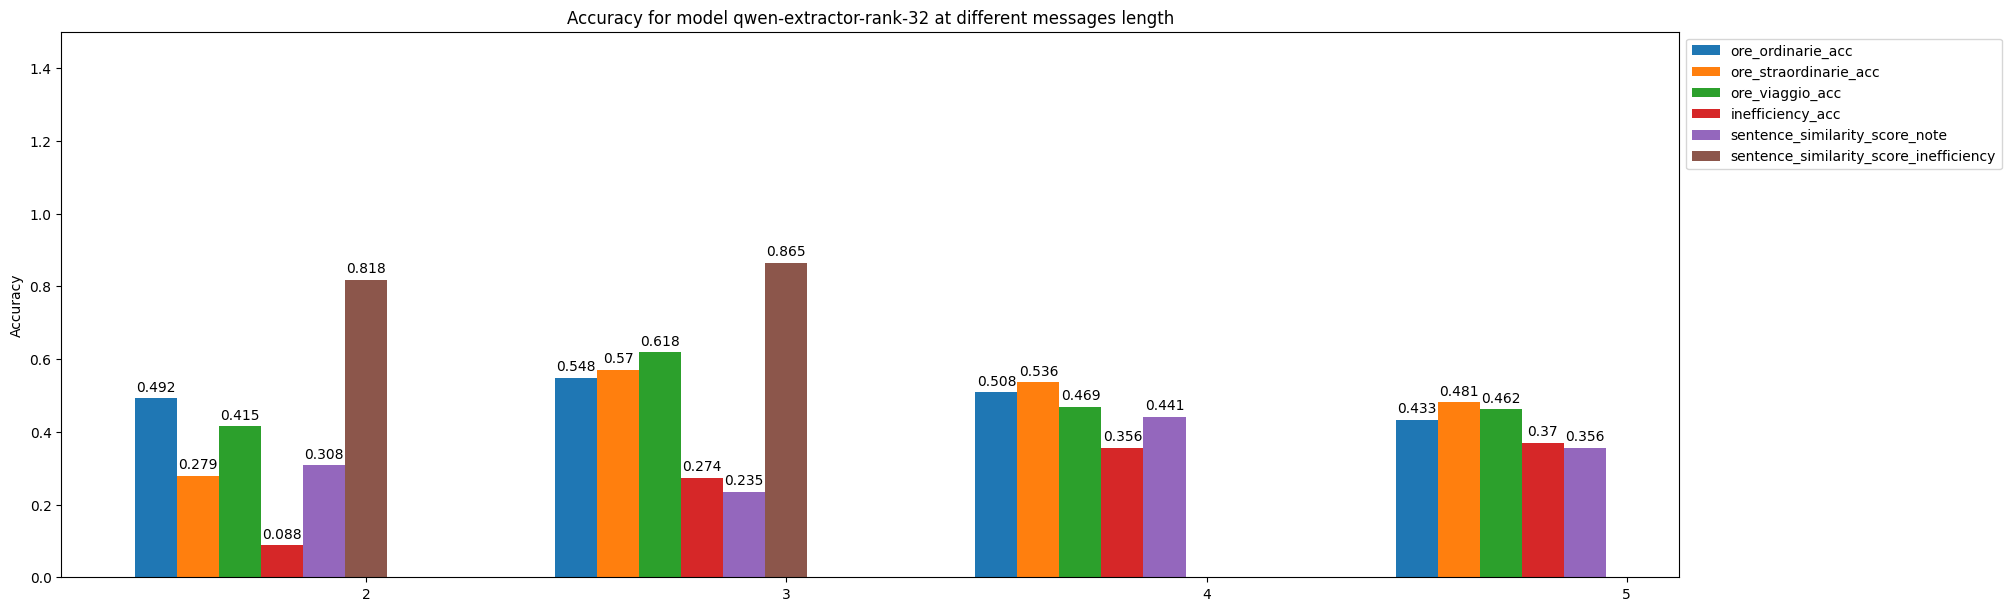

In [9]:
# chart per fare il display accuracy totale  al variare del flow

l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)